# Pipeline, ColumnTransformer, and Data Leakage

This notebook covers the most important practical skills in supervised machine learning:
how to avoid data leakage and how to use sklearn Pipelines to make that easy and automatic.

**Topics covered:**
1. What is Data Leakage?
2. Demonstrating Leakage with a real example
3. sklearn Pipeline: The Fix
4. ColumnTransformer: Handling Mixed Data
5. Pipeline with GridSearchCV
6. StratifiedKFold: The Correct Default for Classification
7. Learning Curves: Diagnosing Bias vs Variance
8. RandomizedSearchCV and Early Stopping

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    RandomizedSearchCV, KFold, StratifiedKFold, learning_curve
)
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from scipy import stats
import time

np.random.seed(42)
print('All imports successful.')

All imports successful.


---
## 1. What is Data Leakage?

**Data leakage** occurs when information from outside the training set contaminates the model,
causing optimistic evaluation that does not hold in production.

The model appears to perform well during evaluation, but fails in the real world because it
was indirectly exposed to information it should never have seen.

### Two Concrete Examples

**Example 1: Scaling before splitting**

If you fit a `StandardScaler` on the full dataset (train + test combined) and *then* split,
the scaler has already computed mean and variance from the test set. When you later
transform the test set, it was already used to define the transformation, the test set
statistics have leaked into the scaler. The result is an inflated accuracy score that will
not generalize to truly unseen data.

**Example 2: Target encoding before splitting**

If you replace categorical values with the mean target value per category using the *full*
dataset before splitting, the encoded features for the training set already contain
information from the test set labels. The model learns patterns that include test-set
information, so evaluation is falsely optimistic.

### The Core Rule

> Any transformation that learns from data (fitting a scaler, imputing missing values,
> encoding categories, selecting features) must be fit **only on training data** and then
> applied separately to training and test data.

---
## 2. Demonstrating Leakage

We use the breast cancer dataset to show the difference between a leaky workflow and a
correct one.

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print(f'Dataset shape: {X.shape}')
print(f'Class distribution: {np.bincount(y)}')

Dataset shape: (569, 30)
Class distribution: [212 357]


In [3]:
# BAD APPROACH: Scale THEN split (data leakage)
# The scaler sees the test set during fit, leakage!

scaler_leaky = StandardScaler()
X_scaled_leaky = scaler_leaky.fit_transform(X)  # Fit on ALL data including future test set

X_train_leaky, X_test_leaky, y_train, y_test = train_test_split(
    X_scaled_leaky, y, test_size=0.2, random_state=42
)

clf_leaky = LogisticRegression(max_iter=1000, random_state=42)
clf_leaky.fit(X_train_leaky, y_train)
score_leaky = clf_leaky.score(X_test_leaky, y_test)

print(f'BAD (leaky) approach test accuracy:  {score_leaky:.6f}')

BAD (leaky) approach test accuracy:  0.973684


In [4]:
# GOOD APPROACH: Split THEN scale (no leakage)
# Scaler only sees training data, no leakage!

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_correct = StandardScaler()
X_train_scaled = scaler_correct.fit_transform(X_train_raw)  # Fit ONLY on training data
X_test_scaled = scaler_correct.transform(X_test_raw)         # Transform test data separately

clf_correct = LogisticRegression(max_iter=1000, random_state=42)
clf_correct.fit(X_train_scaled, y_train)
score_correct = clf_correct.score(X_test_scaled, y_test)

print(f'GOOD (no leakage) approach test accuracy: {score_correct:.6f}')

GOOD (no leakage) approach test accuracy: 0.973684


In [5]:
# Compare both scores side by side
print('=' * 50)
print('Score Comparison')
print('=' * 50)
print(f'  BAD  (leaky, scale then split): {score_leaky:.6f}')
print(f'  GOOD (correct, split then scale): {score_correct:.6f}')
print(f'  Difference (leaky - correct):    {score_leaky - score_correct:+.6f}')
print()
if score_leaky > score_correct:
    print('The leaky approach gives an inflated score.')
    print('In production, the model would perform worse than expected.')
else:
    print('In this case the difference is small, but in high-dimensional')
    print('or noisy datasets the gap can be large and misleading.')

Score Comparison
  BAD  (leaky, scale then split): 0.973684
  GOOD (correct, split then scale): 0.973684
  Difference (leaky - correct):    +0.000000

In this case the difference is small, but in high-dimensional
or noisy datasets the gap can be large and misleading.


**Key takeaway:** Even though the difference looks small here, the leaky workflow gives a
fundamentally wrong estimate of generalization performance. On noisy, high-dimensional,
or small datasets the inflation can be dramatic. The correct approach is to always split
first and fit preprocessing only on training data.

---
## 3. sklearn Pipeline: The Fix

Writing split-then-fit manually is error-prone. The sklearn `Pipeline` automates this
correctly: during cross-validation, each fold's scaler is fit only on that fold's training
data. No leakage is possible.

In [6]:
from sklearn.pipeline import Pipeline

# Build a pipeline: list of (name, estimator) tuples
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

print('Pipeline steps:')
for name, step in pipe.steps:
    print(f'  {name}: {step}')

Pipeline steps:
  scaler: StandardScaler()
  clf: LogisticRegression(max_iter=1000, random_state=42)


In [7]:
# Pipeline with cross_val_score
# At each fold: scaler.fit_transform(X_train_fold), then scaler.transform(X_val_fold)
# The test fold never influences the scaler, no leakage

cv_scores_pipeline = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')

print('Pipeline cross-validation scores (5-fold):')
print(f'  Per-fold: {cv_scores_pipeline.round(4)}')
print(f'  Mean: {cv_scores_pipeline.mean():.4f} +/- {cv_scores_pipeline.std():.4f}')

Pipeline cross-validation scores (5-fold):
  Per-fold: [0.9825 0.9825 0.9737 0.9737 0.9912]
  Mean: 0.9807 +/- 0.0065


In [8]:
# Compare pipeline CV score to the leaky single-split score
print('=' * 55)
print('Comparison: Leaky vs Correct Manual vs Pipeline CV')
print('=' * 55)
print(f'  BAD (leaky single split):   {score_leaky:.4f}')
print(f'  GOOD (correct single split): {score_correct:.4f}')
print(f'  Pipeline (5-fold CV mean):   {cv_scores_pipeline.mean():.4f}')
print()
print('The pipeline CV mean is the most reliable estimate of generalization.')

Comparison: Leaky vs Correct Manual vs Pipeline CV
  BAD (leaky single split):   0.9737
  GOOD (correct single split): 0.9737
  Pipeline (5-fold CV mean):   0.9807

The pipeline CV mean is the most reliable estimate of generalization.


In [9]:
# Pipeline works exactly like a model: fit, predict, score
pipe.fit(X_train_raw, y_train)

predictions = pipe.predict(X_test_raw)
pipeline_test_score = pipe.score(X_test_raw, y_test)

print(f'pipe.fit() then pipe.score() on held-out test: {pipeline_test_score:.4f}')
print(f'First 10 predictions: {predictions[:10]}')
print(f'First 10 true labels: {y_test[:10]}')
print()
print('The pipeline handles all preprocessing internally.')
print('You never need to manually call scaler.transform() at inference time.')

pipe.fit() then pipe.score() on held-out test: 0.9737
First 10 predictions: [1 0 0 1 1 0 0 0 1 1]
First 10 true labels: [1 0 0 1 1 0 0 0 1 1]

The pipeline handles all preprocessing internally.
You never need to manually call scaler.transform() at inference time.


---
## 4. ColumnTransformer: Handling Mixed Data

Real datasets almost always have a mix of numeric and categorical features. The
`ColumnTransformer` lets you apply different transformations to different columns and
then concatenate the results.

In [10]:
from sklearn.compose import ColumnTransformer

# Create a mixed dataset with numeric and categorical columns
X_num, y_mixed = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    random_state=42
)

# Convert to DataFrame and add two categorical columns
df = pd.DataFrame(X_num, columns=[f'num_{i}' for i in range(5)])
df['color'] = np.random.choice(['red', 'green', 'blue'], size=1000, replace=True)
df['size'] = np.random.choice(['small', 'medium', 'large'], size=1000, replace=True)

print('Mixed dataset shape:', df.shape)
print('\nFirst 3 rows:')
print(df.head(3))
print('\nColumn dtypes:')
print(df.dtypes)

Mixed dataset shape: (1000, 7)

First 3 rows:


      num_0     num_1     num_2     num_3     num_4 color   size
0 -0.038769 -0.649239 -0.224746 -1.346275  0.126879  blue  large
1  1.005284 -1.373239  1.157346  0.126493  1.422799   red  large
2 -0.742455 -0.573257  1.688442 -2.588237  0.762562  blue  large

Column dtypes:
num_0    float64
num_1    float64
num_2    float64
num_3    float64
num_4    float64
color     object
size      object
dtype: object


In [11]:
# Define which columns are numeric and which are categorical
numeric_cols = [f'num_{i}' for i in range(5)]
categorical_cols = ['color', 'size']

# Build a ColumnTransformer
# Each tuple: (name, transformer, columns)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'  # Drop any other columns not listed
)

print('ColumnTransformer defined.')
print(f'  Numeric columns ({len(numeric_cols)}):     {numeric_cols}')
print(f'  Categorical columns ({len(categorical_cols)}): {categorical_cols}')

ColumnTransformer defined.
  Numeric columns (5):     ['num_0', 'num_1', 'num_2', 'num_3', 'num_4']
  Categorical columns (2): ['color', 'size']


In [12]:
# Wrap the ColumnTransformer in a Pipeline with a classifier at the end
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print('Full pipeline:')
for name, step in full_pipeline.steps:
    print(f'  {name}: {type(step).__name__}')

Full pipeline:
  preprocessor: ColumnTransformer
  classifier: LogisticRegression


In [13]:
# Fit and evaluate with cross_val_score
# The pipeline handles all column-specific transformations internally
X_df = df  # Use the full DataFrame

cv_scores_mixed = cross_val_score(
    full_pipeline, X_df, y_mixed, cv=5, scoring='accuracy'
)

print('Mixed dataset pipeline cross-validation results:')
print(f'  Per-fold scores: {cv_scores_mixed.round(4)}')
print(f'  Mean accuracy:   {cv_scores_mixed.mean():.4f}')
print(f'  Std deviation:   {cv_scores_mixed.std():.4f}')
print()

# Show what the preprocessor produces
X_train_df, X_test_df, y_train_m, y_test_m = train_test_split(
    X_df, y_mixed, test_size=0.2, random_state=42
)
full_pipeline.fit(X_train_df, y_train_m)
X_transformed = full_pipeline.named_steps['preprocessor'].transform(X_train_df)
print(f'Shape after ColumnTransformer: {X_transformed.shape}')
print(f'  (5 scaled numeric + 3 OHE for color + 3 OHE for size = 11 columns)')

Mixed dataset pipeline cross-validation results:
  Per-fold scores: [0.955 0.885 0.895 0.9   0.935]
  Mean accuracy:   0.9140
  Std deviation:   0.0265

Shape after ColumnTransformer: (800, 11)
  (5 scaled numeric + 3 OHE for color + 3 OHE for size = 11 columns)


---
## 5. Pipeline with GridSearchCV

`GridSearchCV` on a pipeline searches over hyperparameters while respecting the
pipeline structure. Each candidate configuration is evaluated with proper cross-validation,
so preprocessing is fit only on training folds. No leakage occurs during hyperparameter
tuning.

In [14]:
# Build a Pipeline with SimpleImputer + StandardScaler + RandomForestClassifier
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('randomforestclassifier', RandomForestClassifier(random_state=42))
])

print('Pipeline for GridSearchCV:')
for name, step in pipe_rf.steps:
    print(f'  {name}: {type(step).__name__}')

Pipeline for GridSearchCV:
  imputer: SimpleImputer
  scaler: StandardScaler
  randomforestclassifier: RandomForestClassifier


In [15]:
# Define a param_grid using double underscore notation to reference pipeline steps
# Format: 'step_name__parameter_name'
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [None, 5, 10],
}

print('Parameter grid:')
for key, values in param_grid.items():
    print(f'  {key}: {values}')
print(f'Total combinations: {3 * 3} x 5 CV folds = {3 * 3 * 5} fits')

Parameter grid:
  randomforestclassifier__n_estimators: [50, 100, 200]
  randomforestclassifier__max_depth: [None, 5, 10]
Total combinations: 9 x 5 CV folds = 45 fits


In [16]:
# Run GridSearchCV on the pipeline
grid_search = GridSearchCV(
    pipe_rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_raw, y_train)

print('GridSearchCV complete.')
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV score:   {grid_search.best_score_:.4f}')
print(f'Test set score:  {grid_search.score(X_test_raw, y_test):.4f}')

GridSearchCV complete.
Best parameters: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 200}
Best CV score:   0.9626
Test set score:  0.9649


In [17]:
# Show the top 5 configurations
results_df = pd.DataFrame(grid_search.cv_results_)
top5 = results_df[['param_randomforestclassifier__n_estimators',
                    'param_randomforestclassifier__max_depth',
                    'mean_test_score',
                    'std_test_score',
                    'rank_test_score']].sort_values('rank_test_score').head(5)
print('Top 5 configurations:')
print(top5.to_string(index=False))
print()
print('Key point: GridSearchCV with a pipeline ensures that imputation and scaling')
print('are re-fit on each training fold. No leakage occurs during hyperparameter tuning.')

Top 5 configurations:
 param_randomforestclassifier__n_estimators param_randomforestclassifier__max_depth  mean_test_score  std_test_score  rank_test_score
                                        200                                    None         0.962637        0.013187                1
                                        200                                      10         0.962637        0.013187                1
                                        100                                       5         0.960440        0.011207                3
                                        200                                       5         0.958242        0.014579                4
                                        100                                      10         0.958242        0.017582                4

Key point: GridSearchCV with a pipeline ensures that imputation and scaling
are re-fit on each training fold. No leakage occurs during hyperparameter tuning.


---
## 6. StratifiedKFold: The Correct Default for Classification

With plain `KFold`, class proportions in each fold can vary significantly, especially with
imbalanced datasets. `StratifiedKFold` preserves the overall class distribution in each
fold, giving a more reliable and less noisy cross-validation estimate.

In [18]:
# Create an imbalanced dataset: 90% class 0, 10% class 1
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    weights=[0.9, 0.1],
    random_state=42
)

overall_pos_rate = y_imb.mean()
print(f'Imbalanced dataset shape: {X_imb.shape}')
print(f'Class counts: {np.bincount(y_imb)}')
print(f'Overall positive class rate: {overall_pos_rate:.3f} ({overall_pos_rate*100:.1f}%)')

Imbalanced dataset shape: (1000, 20)
Class counts: [896 104]
Overall positive class rate: 0.104 (10.4%)


In [19]:
# Show plain KFold: class proportions vary across folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('Plain KFold - positive class proportion in each fold:')
print(f'  Overall: {overall_pos_rate:.3f}')
print()
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_imb, y_imb)):
    train_pos = y_imb[train_idx].mean()
    val_pos = y_imb[val_idx].mean()
    print(f'  Fold {fold_idx + 1}: train pos={train_pos:.3f}, val pos={val_pos:.3f}')

Plain KFold - positive class proportion in each fold:
  Overall: 0.104

  Fold 1: train pos=0.098, val pos=0.130
  Fold 2: train pos=0.094, val pos=0.145
  Fold 3: train pos=0.111, val pos=0.075
  Fold 4: train pos=0.110, val pos=0.080
  Fold 5: train pos=0.107, val pos=0.090


In [20]:
# Show StratifiedKFold: class proportions match the overall distribution
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('StratifiedKFold - positive class proportion in each fold:')
print(f'  Overall: {overall_pos_rate:.3f}')
print()
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_imb, y_imb)):
    train_pos = y_imb[train_idx].mean()
    val_pos = y_imb[val_idx].mean()
    print(f'  Fold {fold_idx + 1}: train pos={train_pos:.3f}, val pos={val_pos:.3f}')

StratifiedKFold - positive class proportion in each fold:
  Overall: 0.104

  Fold 1: train pos=0.105, val pos=0.100
  Fold 2: train pos=0.104, val pos=0.105
  Fold 3: train pos=0.104, val pos=0.105
  Fold 4: train pos=0.104, val pos=0.105
  Fold 5: train pos=0.104, val pos=0.105


In [21]:
# Compare cross_val_score with KFold vs StratifiedKFold on imbalanced data
clf_imb = LogisticRegression(max_iter=1000, random_state=42)

scores_kf = cross_val_score(clf_imb, X_imb, y_imb, cv=kf, scoring='roc_auc')
scores_skf = cross_val_score(clf_imb, X_imb, y_imb, cv=skf, scoring='roc_auc')

print('ROC-AUC scores on imbalanced dataset:')
print(f'  KFold per fold:          {scores_kf.round(4)}')
print(f'  KFold mean +/- std:      {scores_kf.mean():.4f} +/- {scores_kf.std():.4f}')
print()
print(f'  StratifiedKFold per fold: {scores_skf.round(4)}')
print(f'  StratifiedKFold mean +/- std: {scores_skf.mean():.4f} +/- {scores_skf.std():.4f}')
print()
print('StratifiedKFold typically produces lower variance (more stable scores)')
print('because each fold has the same class distribution.')
print()
print('Rule of thumb: always use StratifiedKFold (or cv=5 in cross_val_score,')
print('which uses StratifiedKFold by default for classifiers).')

ROC-AUC scores on imbalanced dataset:
  KFold per fold:          [0.83   0.8038 0.831  0.8224 0.8193]
  KFold mean +/- std:      0.8213 +/- 0.0098

  StratifiedKFold per fold: [0.7761 0.793  0.859  0.8516 0.846 ]
  StratifiedKFold mean +/- std: 0.8251 +/- 0.0338

StratifiedKFold typically produces lower variance (more stable scores)
because each fold has the same class distribution.

Rule of thumb: always use StratifiedKFold (or cv=5 in cross_val_score,
which uses StratifiedKFold by default for classifiers).


---
## 7. Learning Curves: Diagnosing Bias vs Variance

A **learning curve** plots model performance as a function of training set size.
It reveals whether the model suffers from high bias or high variance:

- **High bias (underfitting):** Both training and validation scores are low and close
  together. Adding more data will not help much. Fix: use a more complex model or add
  more informative features.

- **High variance (overfitting):** Training score is high but validation score is much
  lower. There is a large gap. Fix: get more training data or add regularization.

In [22]:
from sklearn.model_selection import learning_curve

# Create a moderately complex dataset for this demonstration
X_lc, y_lc = make_classification(
    n_samples=2000,
    n_features=30,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

train_sizes = np.linspace(0.05, 1.0, 15)

# High-bias model: Logistic Regression (linear model on complex nonlinear data)
clf_bias = LogisticRegression(C=0.001, max_iter=1000, random_state=42)

train_sizes_abs_bias, train_scores_bias, val_scores_bias = learning_curve(
    clf_bias, X_lc, y_lc,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

# High-variance model: Deep decision tree (memorizes training data)
clf_variance = DecisionTreeClassifier(max_depth=20, random_state=42)

train_sizes_abs_var, train_scores_var, val_scores_var = learning_curve(
    clf_variance, X_lc, y_lc,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

print('Learning curves computed.')

Learning curves computed.


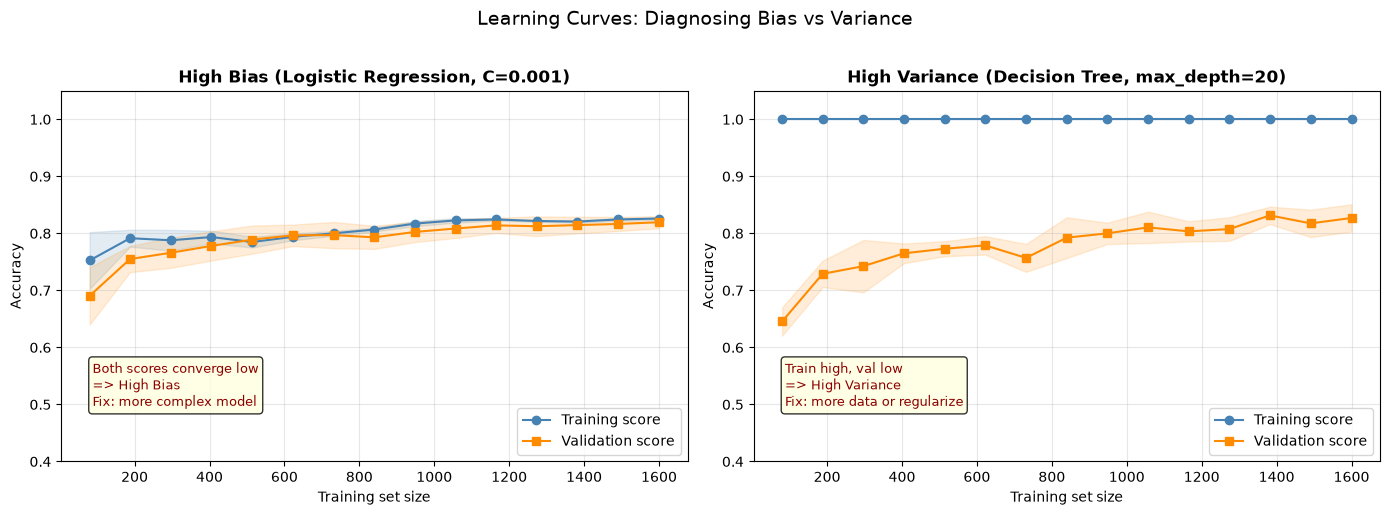

Learning curve interpretation:
  Left plot:  Both curves plateau low   => High Bias   => Need more complexity
  Right plot: Large gap between curves  => High Variance => Need more data or regularization


In [23]:
# Plot both learning curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- High Bias plot ---
ax = axes[0]
train_mean_b = train_scores_bias.mean(axis=1)
train_std_b = train_scores_bias.std(axis=1)
val_mean_b = val_scores_bias.mean(axis=1)
val_std_b = val_scores_bias.std(axis=1)

ax.plot(train_sizes_abs_bias, train_mean_b, 'o-', color='steelblue', label='Training score')
ax.fill_between(train_sizes_abs_bias, train_mean_b - train_std_b, train_mean_b + train_std_b,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes_abs_bias, val_mean_b, 's-', color='darkorange', label='Validation score')
ax.fill_between(train_sizes_abs_bias, val_mean_b - val_std_b, val_mean_b + val_std_b,
                alpha=0.15, color='darkorange')

ax.set_title('High Bias (Logistic Regression, C=0.001)', fontsize=12, fontweight='bold')
ax.set_xlabel('Training set size')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.15, 'Both scores converge low\n=> High Bias\nFix: more complex model',
        transform=ax.transAxes, fontsize=9, color='darkred',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- High Variance plot ---
ax = axes[1]
train_mean_v = train_scores_var.mean(axis=1)
train_std_v = train_scores_var.std(axis=1)
val_mean_v = val_scores_var.mean(axis=1)
val_std_v = val_scores_var.std(axis=1)

ax.plot(train_sizes_abs_var, train_mean_v, 'o-', color='steelblue', label='Training score')
ax.fill_between(train_sizes_abs_var, train_mean_v - train_std_v, train_mean_v + train_std_v,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes_abs_var, val_mean_v, 's-', color='darkorange', label='Validation score')
ax.fill_between(train_sizes_abs_var, val_mean_v - val_std_v, val_mean_v + val_std_v,
                alpha=0.15, color='darkorange')

ax.set_title('High Variance (Decision Tree, max_depth=20)', fontsize=12, fontweight='bold')
ax.set_xlabel('Training set size')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.15, 'Train high, val low\n=> High Variance\nFix: more data or regularize',
        transform=ax.transAxes, fontsize=9, color='darkred',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Learning Curves: Diagnosing Bias vs Variance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Learning curve interpretation:')
print('  Left plot:  Both curves plateau low   => High Bias   => Need more complexity')
print('  Right plot: Large gap between curves  => High Variance => Need more data or regularization')

---
## 8. RandomizedSearchCV and Early Stopping

`GridSearchCV` tries every combination in the parameter grid. With many parameters, this
becomes prohibitively expensive. `RandomizedSearchCV` samples a fixed number of
configurations from the distributions, giving a better search of the space for the same
compute budget.

**Early stopping** in boosting models stops adding new trees when the validation loss
stops improving, preventing overfitting and saving compute.

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from scipy import stats

# Use the breast cancer dataset for this section
X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define a wide parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': stats.randint(50, 300),
    'max_depth': stats.randint(2, 10),
    'learning_rate': stats.loguniform(0.01, 0.5),
    'subsample': stats.uniform(0.5, 0.5),
    'colsample_bytree': stats.uniform(0.5, 0.5),
    'min_child_weight': stats.randint(1, 10)
}

# For comparison, define the same space as a grid (just a subset for speed)
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.3]
}

print('Parameter distribution for RandomizedSearchCV:')
for k, v in param_dist.items():
    print(f'  {k}: {v}')

Parameter distribution for RandomizedSearchCV:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x722483376300>
  max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x72247488a960>
  learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x722474888740>
  subsample: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7224832fb8c0>
  colsample_bytree: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x722479a646e0>
  min_child_weight: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x722474914110>


In [25]:
# GridSearchCV on XGBoost (smaller grid for fair timing comparison)
xgb_clf_grid = xgb.XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)

t0 = time.time()
grid_xgb = GridSearchCV(
    xgb_clf_grid,
    param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_xgb.fit(X_xgb_train, y_xgb_train)
time_grid = time.time() - t0

print(f'GridSearchCV finished in {time_grid:.2f}s')
print(f'  Combinations tested: {3*3*3} x 3 folds = {3*3*3*3} fits')
print(f'  Best params: {grid_xgb.best_params_}')
print(f'  Best CV score: {grid_xgb.best_score_:.4f}')

GridSearchCV finished in 3.71s
  Combinations tested: 27 x 3 folds = 81 fits
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  Best CV score: 0.9670


In [26]:
# RandomizedSearchCV on XGBoost (same number of fits = 27)
xgb_clf_rand = xgb.XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)

t0 = time.time()
rand_xgb = RandomizedSearchCV(
    xgb_clf_rand,
    param_dist,
    n_iter=27,       # Same number of fits as the grid search above
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rand_xgb.fit(X_xgb_train, y_xgb_train)
time_rand = time.time() - t0

print(f'RandomizedSearchCV finished in {time_rand:.2f}s')
print(f'  Configurations sampled: 27 x 3 folds = 81 fits')
print(f'  Best params: {rand_xgb.best_params_}')
print(f'  Best CV score: {rand_xgb.best_score_:.4f}')

RandomizedSearchCV finished in 2.11s
  Configurations sampled: 27 x 3 folds = 81 fits
  Best params: {'colsample_bytree': np.float64(0.7623873301291946), 'learning_rate': np.float64(0.047791624922363225), 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 157, 'subsample': np.float64(0.7571172192068059)}
  Best CV score: 0.9692


In [27]:
# Compare results
print('=' * 60)
print('GridSearchCV vs RandomizedSearchCV Comparison')
print('=' * 60)
print(f'  GridSearchCV:      CV={grid_xgb.best_score_:.4f}, time={time_grid:.2f}s')
print(f'                     searched {3*3*3} fixed combinations')
print(f'  RandomizedSearchCV: CV={rand_xgb.best_score_:.4f}, time={time_rand:.2f}s')
print(f'                     searched 27 random samples from wide distributions')
print()
print('RandomizedSearchCV explores a much wider space of hyperparameters')
print('with the same or fewer evaluations compared to an exhaustive grid.')
print('With high-dimensional param spaces, RandomizedSearchCV consistently wins.')

GridSearchCV vs RandomizedSearchCV Comparison
  GridSearchCV:      CV=0.9670, time=3.71s
                     searched 27 fixed combinations
  RandomizedSearchCV: CV=0.9692, time=2.11s
                     searched 27 random samples from wide distributions

RandomizedSearchCV explores a much wider space of hyperparameters
with the same or fewer evaluations compared to an exhaustive grid.
With high-dimensional param spaces, RandomizedSearchCV consistently wins.


In [28]:
# Early stopping with XGBoost
# Train on a training split, validate on a validation split
# XGBoost stops adding trees when the validation metric stops improving

X_es_train, X_es_val, y_es_train, y_es_val = train_test_split(
    X_xgb_train, y_xgb_train, test_size=0.2, random_state=42
)

xgb_early = xgb.XGBClassifier(
    n_estimators=500,        # Allow up to 500 trees
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss',
    early_stopping_rounds=20,  # moved to constructor (XGBoost >= 2.0)
    random_state=42,
    verbosity=0
)

# eval_set provides a validation set for monitoring
# early_stopping_rounds=20 stops if val loss does not improve for 20 consecutive rounds
xgb_early.fit(
    X_es_train, y_es_train,
    eval_set=[(X_es_val, y_es_val)],
    verbose=False
)

print(f'Configured max trees: 500')
print(f'Trees actually used:  {xgb_early.best_iteration + 1}')
print(f'Best validation logloss: {xgb_early.best_score:.4f}')
print(f'Test set accuracy: {xgb_early.score(X_xgb_test, y_xgb_test):.4f}')
print()
print('Early stopping saved compute by stopping before 500 trees.')
print('It also prevents overfitting by selecting the optimal number of boosting rounds.')

Configured max trees: 500
Trees actually used:  94
Best validation logloss: 0.1705
Test set accuracy: 0.9561

Early stopping saved compute by stopping before 500 trees.
It also prevents overfitting by selecting the optimal number of boosting rounds.


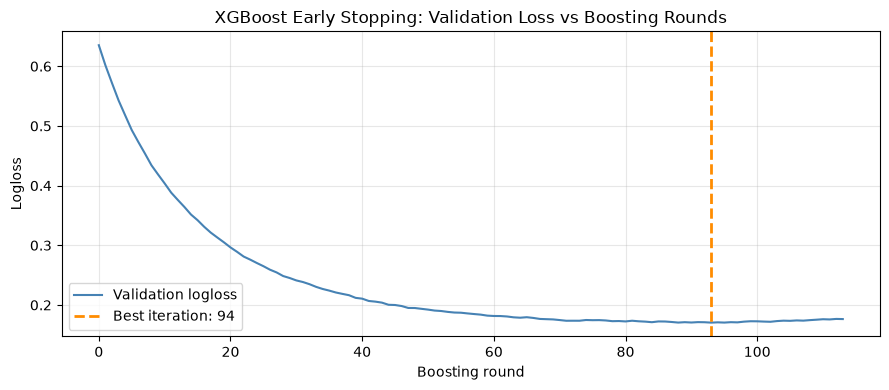

Validation loss stopped improving after round 94.
Training would have overfit if all 500 rounds were used.


In [29]:
# Plot the validation loss curve to visualize early stopping
evals_result = xgb_early.evals_result()
val_logloss = evals_result['validation_0']['logloss']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(val_logloss, color='steelblue', linewidth=1.5, label='Validation logloss')
ax.axvline(x=xgb_early.best_iteration, color='darkorange', linestyle='--',
           linewidth=2, label=f'Best iteration: {xgb_early.best_iteration + 1}')
ax.set_xlabel('Boosting round')
ax.set_ylabel('Logloss')
ax.set_title('XGBoost Early Stopping: Validation Loss vs Boosting Rounds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Validation loss stopped improving after round {xgb_early.best_iteration + 1}.')
print('Training would have overfit if all 500 rounds were used.')

---
## Summary

| Concept | Key point |
|---|---|
| Data leakage | Fitting any transformer on the full dataset before splitting causes optimistic evaluation |
| Pipeline | Automates correct preprocessing within cross-validation; eliminates leakage |
| ColumnTransformer | Applies different transformations to different column types in one step |
| GridSearchCV + Pipeline | Hyperparameter search with no leakage; uses double underscore notation |
| StratifiedKFold | Preserves class proportions in each fold; always use for classification |
| Learning curves | High bias: both scores low; High variance: large gap between train and val |
| RandomizedSearchCV | Samples parameter distributions; better than grid search for wide spaces |
| Early stopping | Stops boosting when validation loss plateaus; prevents overfitting and saves compute |

**The single most important habit:** put all preprocessing inside a Pipeline before calling
`cross_val_score`, `GridSearchCV`, or `RandomizedSearchCV`. Everything else follows from that.